# Trabajo Práctico N°7 del TPS: PCA, K-means y EM

En este trabajo práctico se implementa un algoritmo de PCA condicional para aprender una curva representativa de un *manifold* 2D no lineal. La idea es combinar un algoritmo de clustering (K-Means y luego EM) con un PCA por cluster, de manera que cada cluster aproxime localmente una recta del manifold. Finalmente, se utiliza el error de reconstrucción del PCA como detector de anomalías.



Se importan las librerías que se utilizarán a lo largo del mismo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Inciso A: Creación del *dataset*



El objetivo de este inciso es generar datos sintéticos que simulen mediciones ruidosas de una curva en el plano. La curva subyacente (el manifold) es un triángulo formado por tres segmentos de recta, definido por la función $g(u)$ para $u \in [0, 1]$.

La curva subyacente se llama manifold: es una curva parametrizada $g(u)$ con $u \in [0,1]$, exactamente igual a las parametrizaciones de Análisis II. Con un solo parámetro $u$ se puede ubicar cualquier punto de la curva, aunque esa curva viva en $\mathbb{R}^2$. En este caso, $g(u)$ traza un triángulo, sube en diagonal, baja en diagonal, y vuelve horizontalmente al origen.

Para generar los datos se realiza una simulación de Monte Carlo con dos fuentes de aleatoriedad:
- $U_i \sim \mathcal{U}(0,1)$: elige un punto al azar a lo largo de la curva.
- $Z_i \sim \mathcal{N}(0, I)$: agrega ruido gaussiano en todas las direcciones, simulando error de medición.

El resultado es una nube de 200 puntos distribuidos cerca del triángulo. El objetivo de todo el TP es que los algoritmos recuperen ese triángulo a partir de los datos, sin saber de antemano que es un triángulo.

In [2]:
np.random.seed(42)

N = 200

# Sortear U_i ~ Uniform(0,1)
U = np.random.uniform(0, 1, N)

# Evaluar g(u) — tres tramos lineales
def g(u):
    x = np.where(u < 1/3,  1.5 * u,
        np.where(u < 2/3,  1.5 * u,
                            3 - 3 * u))
    y = np.where(u < 1/3,  3 * u,
        np.where(u < 2/3,  2 - 3 * u,
                            np.zeros_like(u)))
    return np.column_stack([x, y])

G = g(U)

# Ruido gaussiano estándar bivariado
Z = np.random.randn(N, 2)

X = G + 0.05 * Z

Se grafica el *scatter* y el *mainfold* en el mismo plano.

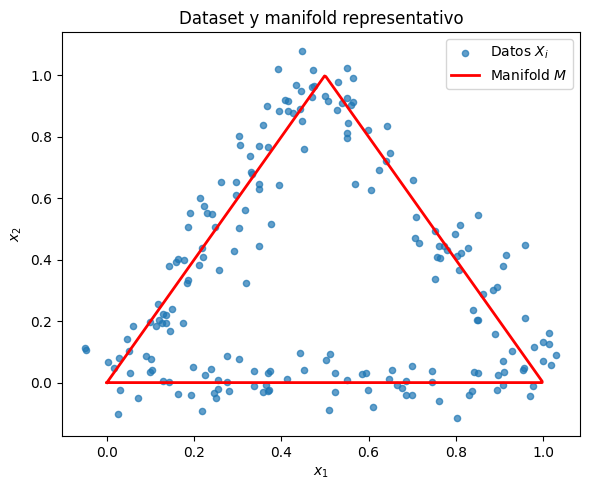

In [3]:
# Curva representativa del manifold (sin ruido)
u_curve = np.linspace(0, 1, 500)
M = g(u_curve)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7, label='Datos $X_i$')
ax.plot(M[:, 0], M[:, 1], color='red', linewidth=2, label='Manifold $M$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Dataset y manifold representativo')
ax.legend()
plt.tight_layout()
plt.show()

El gráfico muestra lo esperado: los 200 puntos forman tres nubes alargadas, una por cada lado del triángulo, y la curva roja pasa por el centro de cada nube. El ruido es pequeño pero visible. Hay dispersión perpendicular a cada lado, simulando correctamente el error de medición.

A partir de esta visualización se puede anticipar el comportamiento de los algoritmos de clustering:

- **K-Means:** agrupa por distancia al centroide, asumiendo clusters circulares (isótropos). Esto puede ser problemático acá porque los tres grupos son claramente alargados y orientados en distintas direcciones. En las esquinas del triángulo, donde se juntan puntos de dos lados distintos, K-Means puede cometer errores de asignación.
- **EM:** modela cada cluster con una Gaussiana completa (con covarianza), por lo que puede capturar la forma alargada de cada lado. Se espera que encuentre los tres grupos con mayor precisión.

## Inciso B: K-Means

Se implementa el algoritmo K-Means para clusterizar los datos. El primer paso es elegir $K$, la cantidad de clusters.

En la práctica, $K$ no se conoce de antemano. Las estrategias habituales son probar varios valores y usar métricas como el método del codo -**ver que onda eso**- (graficar la inercia en función de $K$ y buscar el punto donde la mejora se vuelve marginal) o el silhouette score (qué tan bien separado está cada punto de los clusters vecinos). Es análogo a elegir el orden de un filtro en telecomunicaciones: probás distintos órdenes y buscás el punto donde agregar más no mejora significativamente la respuesta.

En este caso se usa conocimiento del dominio: el manifold tiene 3 lados, por lo que $K = 3$ es la elección natural. En telecomunicaciones sería como saber de antemano cuántas fuentes de señal hay. Cada cluster debería capturar un lado del triángulo.

### Implementación

La clase `KMeans` se construye con la misma estructura que en el TP6: inicialización aleatoria de centroides, reasignación por distancia euclidiana y actualización iterativa hasta convergencia.

Los hiperparámetros son:
- `max_iter=300`: cota de seguridad para que el algoritmo no corra indefinidamente si no converge. En la práctica K-Means converge en pocas iteraciones para datasets chicos.
- `tol=1e-4`: el algoritmo se detiene cuando el desplazamiento de los centroides entre iteraciones es menor a este umbral. Es el criterio de convergencia.
- `random_state=0`: fija la semilla de inicialización para reproducibilidad. En general, se recomienda correr K-Means varias veces con distintas semillas y quedarse con la solución de menor inercia, ya que la inicialización aleatoria puede llevar a óptimos locales. En este caso, sin embargo, no vale la pena: como se anticipó en el análisis del inciso A, el problema no es la inicialización sino la suposición del modelo K-Means asume clusters esféricos, y los datos tienen forma alargada. Ninguna inicialización va a corregir ese desajuste estructural.

In [4]:
class KMeans:
    def __init__(self, k=3, max_iter=300, tol=1e-4, random_state=0):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.n_iter_ = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(len(X), self.k, replace=False)
        self.centroids = X[idx].astype(float).copy()

        for it in range(self.max_iter):
            labels = self._assign(X)

            new_centroids = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j)
                else self.centroids[j]
                for j in range(self.k)
            ])

            shift = np.max(np.linalg.norm(new_centroids - self.centroids, axis=1))
            self.centroids = new_centroids

            if shift < self.tol:
                self.n_iter_ = it + 1
                print(f'Convergió en {self.n_iter_} iteraciones (shift = {shift:.2e})')
                break
        else:
            self.n_iter_ = self.max_iter
            print(f'Máximo de iteraciones alcanzado ({self.max_iter})')

    def _assign(self, X):
        dists = np.linalg.norm(X[:, None, :] - self.centroids[None, :, :], axis=2)
        return np.argmin(dists, axis=1)

    def predict(self, X):
        return self._assign(X)

### Entrenamiento y visualización

Convergió en 5 iteraciones (shift = 0.00e+00)


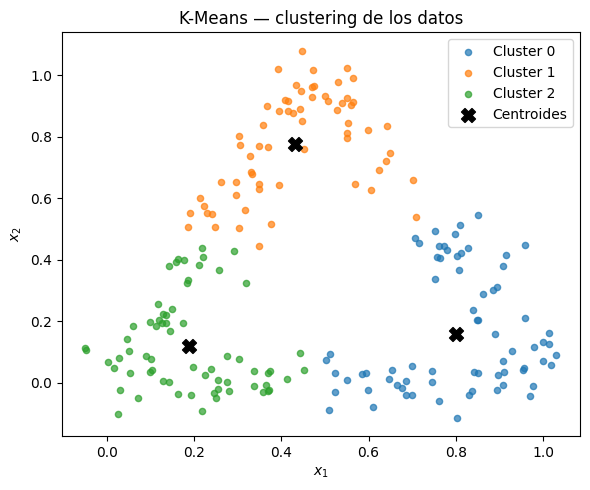

In [5]:
km = KMeans(k=3)
km.fit(X)
labels_km = km.predict(X)

colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(6, 5))
for j in range(km.k):
    mask = labels_km == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.scatter(km.centroids[:, 0], km.centroids[:, 1], s=100, marker='X', color='black', zorder=5, label='Centroides')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('K-Means — clustering de los datos')
ax.legend()
plt.tight_layout()
plt.show()

El algoritmo convergió en solo 5 iteraciones.

El gráfico valida la hipótesis planteada en el inciso A: los tres clusters recuperan aproximadamente los tres lados del triángulo, pero aparecen errores sistemáticos en las esquinas, donde puntos de un lado quedan asignados al cluster del lado adyacente. Esto es exactamente lo que se esperaba: K-Means asigna cada punto al centroide más cercano en distancia euclidiana, asumiendo implícitamente que los clusters son esféricos e isótropos. Los lados del triángulo son estructuras alargadas y orientadas, no círculos por lo tanto K-Means no es el modelo adecuado para esta geometría.

### ¿Es suficiente K-Means para esta tarea?

**No.** K-Means agrupa por proximidad al centroide sin considerar la orientación ni la forma de los clusters. En las esquinas del triángulo, un punto puede estar más cerca del centroide del lado adyacente que del centroide de su propio lado, simplemente porque los centroides quedan en el medio de cada lado. Esto genera errores de asignación sistemáticos en las zonas de transición entre segmentos.

Para capturar correctamente la geometría alargada de cada lado se necesita un modelo que modele también la covarianza de cada cluster, es decir, el algoritmo EM con mezclas de Gaussianas.

## Inciso C: Algoritmo Expectation-Maximization (EM)


K-Means no fue suficiente porque asume que todos los clusters son esféricos — le fija la covarianza a la identidad y solo aprende el centro de cada grupo. Pero los datos tienen forma alargada: cada lado del triángulo es una nube orientada en una dirección, no un círculo. Ninguna inicialización ni ningún ajuste de K-Means puede corregir eso, porque el problema es estructural del modelo.

Para resolverlo se necesita un algoritmo que aprenda también la **forma** de cada cluster, no solo su centro. Ese algoritmo es **EM** (*Expectation-Maximization*), y el modelo subyacente es una **mezcla de gaussianas**.

### El modelo: mezcla de gaussianas

La idea es asumir que los datos fueron generados por $K$ fuentes gaussianas mezcladas. Cada fuente tiene:
- una **media** $\mu_k$: el centro del cluster,
- una **covarianza** $\Sigma_k$: la forma y orientación del cluster (libre, no fija),
- un **peso** $\pi_k$: qué fracción de los datos proviene de esa fuente.

A diferencia de K-Means, donde cada punto pertenece exactamente a un cluster, en el modelo de mezcla cada punto puede haber venido de cualquier fuente. Lo que se observa es el punto; de cuál fuente vino es una **variable oculta** que no se conoce.

### El problema del huevo y la gallina

Esto genera un dilema circular:
- Si se supiera de qué fuente vino cada punto, se podrían estimar fácilmente $\mu_k$, $\Sigma_k$ y $\pi_k$ como promedios ponderados.
- Si se conocieran $\mu_k$, $\Sigma_k$ y $\pi_k$, se podría calcular fácilmente la probabilidad de que cada punto venga de cada fuente.

EM resuelve este dilema alternando entre los dos pasos hasta converger.

### Paso E (Expectation): ¿de dónde vino cada punto?

Dados los parámetros actuales, se calcula para cada punto $x_i$ la **responsabilidad** $r_{ik}$: qué tan probable es que haya venido de la fuente $k$. Esto es simplemente la regla de Bayes:

$$r_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

El numerador es la densidad de la gaussiana $k$ evaluada en $x_i$, pesada por la probabilidad a priori $\pi_k$ de esa fuente. El denominador normaliza para que las responsabilidades sumen 1. Un punto en la frontera entre dos clusters puede tener $r_{i1} = 0.6$ y $r_{i2} = 0.4$ — pertenece parcialmente a ambos. Esto es lo que distingue a EM de K-Means: la asignación es **blanda**, no dura.

### Paso M (Maximization): ¿cómo quedan los parámetros?

Dados los $r_{ik}$, se actualizan los parámetros como promedios ponderados donde el peso de cada punto en el cluster $k$ es su responsabilidad $r_{ik}$:

$$\mu_k = \frac{\sum_i r_{ik} \, x_i}{\sum_i r_{ik}}, \qquad \Sigma_k = \frac{\sum_i r_{ik} \, (x_i - \mu_k)(x_i - \mu_k)^T}{\sum_i r_{ik}}, \qquad \pi_k = \frac{\sum_i r_{ik}}{N}$$

La media es el centroide ponderado. La covarianza es la dispersión ponderada alrededor de ese centroide — si los puntos con alto $r_{ik}$ están distribuidos a lo largo de una recta, $\Sigma_k$ se estira en esa dirección. Los pesos $\pi_k$ reflejan cuántos puntos "pertenecen" a cada fuente.

### La convergencia

EM garantiza que la **log-verosimilitud** $\mathcal{L} = \sum_i \log p(x_i)$ nunca decrece entre iteraciones. Intuitivamente, esto mide qué tan bien el modelo explica los datos observados: una gaussiana estirada en la dirección de una nube alargada tiene mayor densidad sobre esos puntos que una esférica, por lo que contribuye más a $\mathcal{L}$. El algoritmo se detiene cuando la mejora entre iteraciones cae por debajo de un umbral `tol`.

### Comparación con K-Means

| | K-Means | EM |
|---|---|---|
| Forma del cluster | esférica (fija) | libre (aprende $\Sigma_k$) |
| Asignación de puntos | dura (un cluster) | blanda ($r_{ik} \in [0,1]$) |
| Parámetros | solo $\mu_k$ | $\mu_k$, $\Sigma_k$, $\pi_k$ |
| Criterio de convergencia | desplazamiento de centroides | log-verosimilitud |

K-Means es de hecho un caso límite de EM: si se fija $\Sigma_k = I$ para todo $k$ y se llevan las responsabilidades a 0 o 1 (asignación dura), se recupera exactamente el algoritmo K-Means.

### Implementación


In [6]:
class EM:
    def __init__(self, k=3, max_iter=100, tol=1e-4, random_state=0):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.pi = None      # pesos (K,)
        self.mu = None      # medias (K, d)
        self.sigma = None   # covarianzas (K, d, d)
        self.n_iter_ = None

    def _gauss(self, X, k):
        d = X.shape[1]
        diff = X - self.mu[k]
        inv_sigma = np.linalg.inv(self.sigma[k])
        det_sigma = np.linalg.det(self.sigma[k])
        norm = 1 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_sigma))
        exp_term = np.exp(-0.5 * np.einsum('ni,ij,nj->n', diff, inv_sigma, diff))
        return norm * exp_term

    def fit(self, X):
        N, d = X.shape
        rng = np.random.default_rng(self.random_state)

        # Inicialización: muestras al azar, pesos equiprobables, covarianzas identidad
        idx = rng.choice(N, self.k, replace=False)
        self.mu = X[idx].astype(float).copy()
        self.pi = np.ones(self.k) / self.k
        self.sigma = np.array([np.eye(d) for _ in range(self.k)])

        log_lik_prev = -np.inf

        for it in range(self.max_iter):
            # E-step
            R = self.predict_proba(X)   # (N, K)

            # M-step
            Nk = R.sum(axis=0)          # (K,)
            self.pi = Nk / N
            self.mu = (R.T @ X) / Nk[:, None]
            for k in range(self.k):
                diff = X - self.mu[k]
                self.sigma[k] = (R[:, k, None] * diff).T @ diff / Nk[k]

            # Criterio de convergencia: log-verosimilitud
            log_lik = np.sum(np.log(
                sum(self.pi[k] * self._gauss(X, k) for k in range(self.k)) + 1e-300
            ))

            if abs(log_lik - log_lik_prev) < self.tol:
                self.n_iter_ = it + 1
                print(f'Convergió en {self.n_iter_} iteraciones (Δlog-lik = {abs(log_lik - log_lik_prev):.2e})')
                break
            log_lik_prev = log_lik
        else:
            self.n_iter_ = self.max_iter
            print(f'Máximo de iteraciones alcanzado ({self.max_iter})')

    def predict_proba(self, X):
        R = np.column_stack([self.pi[k] * self._gauss(X, k) for k in range(self.k)])
        R /= R.sum(axis=1, keepdims=True)
        return R

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

### Entrenamiento y visualización

Convergió en 34 iteraciones (Δlog-lik = 7.21e-05)


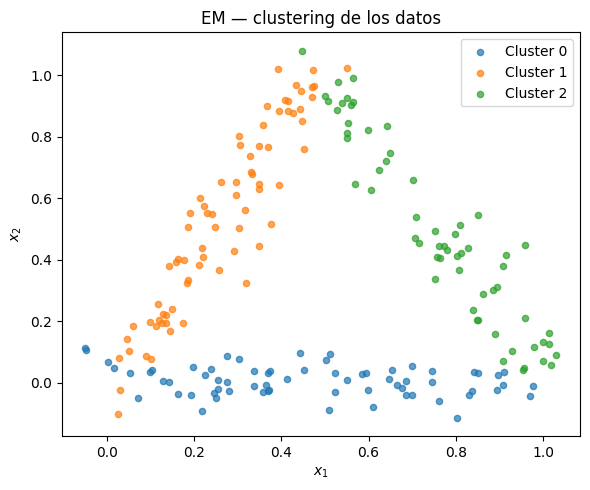

In [7]:
em = EM(k=3)
em.fit(X)
labels_em = em.predict(X)

colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(6, 5))
for j in range(em.k):
    mask = labels_em == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('EM — clustering de los datos')
ax.legend()
plt.tight_layout()
plt.show()

### Fronteras de decisión

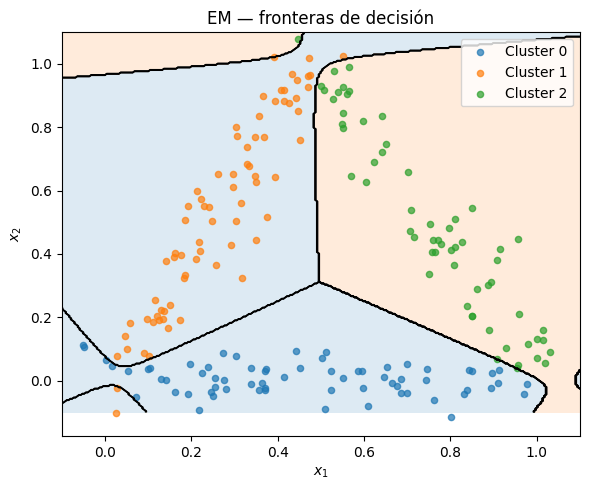

In [8]:
xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 300), np.linspace(-0.1, 1.1, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
Z = em.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, alpha=0.15, colors=colors)
ax.contour(xx, yy, Z, colors='k', linewidths=0.8)
for j in range(em.k):
    mask = labels_em == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('EM — fronteras de decisión')
ax.legend()
plt.tight_layout()
plt.show()

### Sensibilidad a la inicialización

Se corre EM 8 veces con distintas semillas para ver si la inicialización aleatoria afecta el resultado final.

Convergió en 34 iteraciones (Δlog-lik = 7.21e-05)
Convergió en 29 iteraciones (Δlog-lik = 5.27e-05)
Convergió en 33 iteraciones (Δlog-lik = 5.77e-05)
Convergió en 27 iteraciones (Δlog-lik = 5.54e-05)
Convergió en 28 iteraciones (Δlog-lik = 6.55e-05)
Convergió en 31 iteraciones (Δlog-lik = 4.06e-05)
Convergió en 29 iteraciones (Δlog-lik = 6.70e-05)
Convergió en 29 iteraciones (Δlog-lik = 7.72e-05)
Convergió en 30 iteraciones (Δlog-lik = 6.70e-05)
Convergió en 34 iteraciones (Δlog-lik = 5.07e-05)
Convergió en 22 iteraciones (Δlog-lik = 6.04e-05)
Convergió en 30 iteraciones (Δlog-lik = 4.76e-05)
Convergió en 25 iteraciones (Δlog-lik = 9.11e-05)
Convergió en 36 iteraciones (Δlog-lik = 6.82e-05)


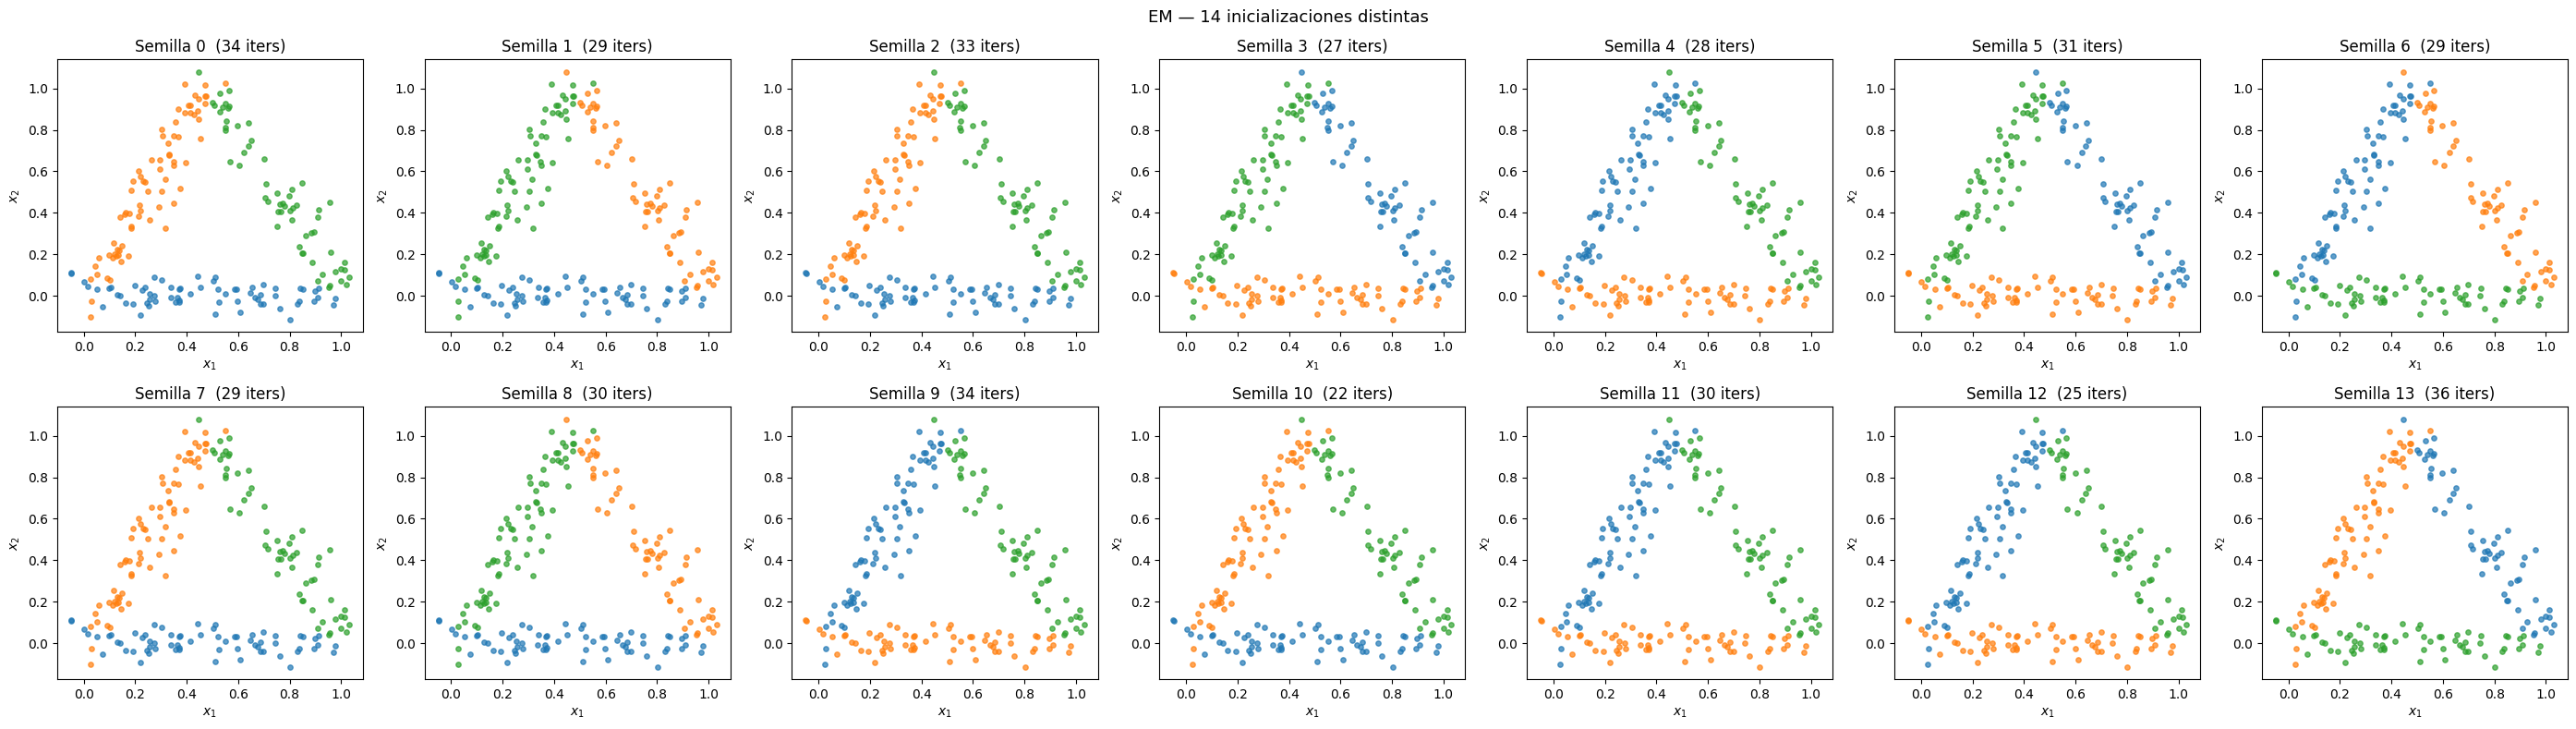

In [11]:
n_runs = 14
seeds = range(n_runs)
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 7, figsize=(28, 8))
axes = axes.ravel()

for i, seed in enumerate(seeds):
    em_i = EM(k=3, random_state=seed)
    em_i.fit(X)
    labels_i = em_i.predict(X)

    ax = axes[i]
    for j in range(em_i.k):
        mask = labels_i == j
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, color=colors[j])
    ax.set_title(f'Semilla {seed}  ({em_i.n_iter_} iters)')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.suptitle('EM — 14 inicializaciones distintas', fontsize=13)
plt.tight_layout()
plt.show()

Las 14 inicializaciones convergen al mismo resultado. A primera vista esto parece contradictorio: la probabilidad de que los tres centroides iniciales queden distribuidos uno por cada lado es solo $1 \times \frac{2}{3} \times \frac{1}{3} \approx 22\%$, por lo que en la mayoría de los casos al menos dos centroides arrancan en el mismo lado.

El mecanismo de recuperación es el siguiente. Supongamos que $\mu_1$ y $\mu_2$ arrancan en la base y $\mu_3$ en el lado izquierdo, quedando el lado derecho sin cubrir. En el primer E-step, los puntos del lado derecho están lejos de los tres centroides, por lo que sus responsabilidades se reparten casi en tercios entre los tres clusters. Esto tiene dos efectos: (1) $\mu_1$ y $\mu_2$ compiten por la base y cada uno termina cubriendo una mitad distinta, y (2) ambos reciben algo de "masa" del lado derecho, lo que los tira levemente hacia esa dirección. El centroide que quedó con la mitad de la base más cercana al lado derecho recibe en iteraciones sucesivas una responsabilidad creciente de esos puntos, lo que lo desplaza progresivamente hacia allí hasta que termina cubriendo ese lado.

Este mecanismo de autocorrección funciona en este dataset porque la separación entre los tres lados es mucho mayor que el ruido interno ($\sigma = 0.05$): la asimetría generada por la competencia entre centroides es suficiente para romper el empate y redirigir uno de ellos. Si los lados estuvieran más cerca o el ruido fuera mayor, ese desequilibrio inicial podría no ser suficiente y EM quedaría atrapado con dos clusters en el mismo lado. En esos casos, la práctica estándar es correr EM múltiples veces y quedarse con la solución de mayor log-verosimilitud final.